# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

### Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import LSTM
from keras.callbacks import ModelCheckpoint
from keras.utils import np_utils
from glob import glob
import seaborn as sns
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import os
import cv2

Using TensorFlow backend.


### Change directory

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


### Load the training data from train.csv file

In [0]:
df = pd.read_csv("/content/drive/My Drive/LSTM/train_labels.csv")

### Print the shape of the train dataset

In [4]:
df.shape

(173, 8)

### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [5]:
IMAGE_SIZE = 128
!mkdir "/content/drive/My Drive/LSTM/resized"
resized_folder = "/content/drive/My Drive/LSTM/resized"

mkdir: cannot create directory ‘/content/drive/My Drive/LSTM/resized’: File exists


### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

In [6]:

train_folder = "/content/drive/My Drive/LSTM/images"
images_per_class = {}
path = []
coords = []
print(glob(train_folder))


['/content/drive/My Drive/LSTM/images']


In [0]:

filename = df['filename']
img_path = []
for name in filename:
    img_path = path +'R9_Images/' + filename
    img_path.append(img_path)
for i,j in df.iterrows():
  w = j['width']
  h = j['height']
  x0 = j['xmin']
  y0 = j['ymin']
  x1 = j['xmax']
  y1 = j['ymax']
  class_folder_path = os.path.join(train_folder, j['filename'])
  path.append(class_folder_path)
  x_ratio = IMAGE_SIZE /w;
  y_ratio = IMAGE_SIZE /h;
  x0_new = x0 * x_ratio
  x1_new = x1 * x_ratio
  y0_new = y0 * y_ratio
  y1_new = y1 * y_ratio
  coords.append((x0_new,y0_new,x1_new,y1_new))

  #print (class_folder_path, (x0_new,y0_new,x1_new,y1_new))
  

In [36]:
path[1]

'/content/drive/My Drive/LSTM/images/raccoon-11.jpg'

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

In [0]:
from PIL import Image
from keras.applications.mobilenet import MobileNet, preprocess_input

batch_images = np.zeros((len(path), IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32)
for i in range(0,len(path)):
    img = Image.open(path[i]) # Read image
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE)) # Resize image
    img = img.convert('RGB')
    batch_images[i] = preprocess_input(np.array(img, dtype=np.float32))
        

### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

In [0]:
import keras
import tensorflow as tf
from keras import Model
from keras.layers import Conv2D, Reshape, MaxPooling2D
from keras.applications import MobileNet
mobile = keras.applications.mobilenet.MobileNet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, alpha=1)
#mobile.summary()

In [21]:
#mobile.summary()
print(len(mobile.layers))
for layer in mobile.layers[:]:
    layer.trainable = False
x = mobile.layers[-1].output
x = Conv2D(4, kernel_size=4, name="coords")(x)
x = Reshape((4,))(x)
mobile = Model(inputs=mobile.input, outputs=x)

87


In [23]:
mobile.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
conv1_pad (ZeroPadding2D)    (None, 129, 129, 3)       0         
_________________________________________________________________
conv1 (Conv2D)               (None, 64, 64, 32)        864       
_________________________________________________________________
conv1_bn (BatchNormalization (None, 64, 64, 32)        128       
_________________________________________________________________
conv1_relu (ReLU)            (None, 64, 64, 32)        0         
_________________________________________________________________
conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)        288       
_________________________________________________________________
conv_dw_1_bn (BatchNormaliza (None, 64, 64, 32)        128 

### Define a custom loss function IoU which calculates Intersection Over Union

In [0]:
coords = np.zeros((len(path), 4))
coords.shape
gt = coords
def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#     Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou

def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

In [0]:
from keras.models import Sequential, Model
from keras.layers import Reshape, Activation, Conv2D, Input, MaxPooling2D, BatchNormalization, Flatten, Dense, Lambda
from keras.layers.advanced_activations import LeakyReLU
from keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from keras.optimizers import SGD, Adam, RMSprop
from keras.layers.merge import concatenate
import matplotlib.pyplot as plt
import keras.backend as K
from keras.backend import epsilon
mobile.compile(loss='mse',metrics=[IoU],optimizer='Adam')



### Pick a test image from the given data

In [40]:
mobile.fit(batch_images,gt,
              batch_size=32, nb_epoch=30,
              verbose=1)


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  This is separate from the ipykernel package so we can avoid doing imports until


Epoch 1/30
173/173 [==============================] - 2s 14ms/step - loss: 25.6636 - IoU: 0.0000e+00
Epoch 2/30
173/173 [==============================] - 0s 1ms/step - loss: 10.8961 - IoU: 0.0798
Epoch 3/30
173/173 [==============================] - 0s 1ms/step - loss: 9.1273 - IoU: 0.0292
Epoch 4/30
173/173 [==============================] - 0s 1ms/step - loss: 5.7750 - IoU: 0.1482
Epoch 5/30
173/173 [==============================] - 0s 1ms/step - loss: 3.8221 - IoU: 0.0990
Epoch 6/30
173/173 [==============================] - 0s 1ms/step - loss: 2.6053 - IoU: 0.0639
Epoch 7/30
173/173 [==============================] - 0s 1ms/step - loss: 2.3468 - IoU: 0.2400
Epoch 8/30
173/173 [==============================] - 0s 1ms/step - loss: 1.9493 - IoU: 0.0581
Epoch 9/30
173/173 [==============================] - 0s 1ms/step - loss: 1.4312 - IoU: 0.1135
Epoch 10/30
173/173 [==============================] - 0s 1ms/step - loss: 1.4855 - IoU: 0.1079
Epoch 11/30
173/173 [=====================

### Resize the image to 128 * 128 and preprocess the image for the MobileNet model

In [0]:
unscaled=Image.open(path[12])
scaled=unscaled.resize((128, 128))
scaled=preprocess_input(np.array(scaled, dtype=np.float32))

### Predict the coordinates of the bounding box for the given test image

In [49]:
region = mobile.predict(x=np.array([scaled]))[0]
region

array([ 3.050737  ,  4.809852  ,  1.4858518 , -0.46934924], dtype=float32)

### Plot the test image using .imshow and draw a boundary box around the image with the coordinates obtained from the model

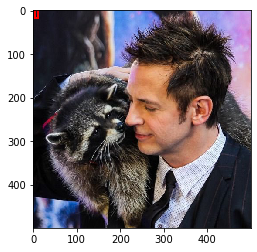

In [50]:
image_width,image_height = unscaled.size
x0 = int(region[0] * image_width / IMAGE_SIZE) # Scale the BBox
y0 = int(region[1] * image_height / IMAGE_SIZE)

x1 = int((region[2]) * image_width / IMAGE_SIZE)
y1 = int((region[3]) * image_height / IMAGE_SIZE)


import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(unscaled)

# Create a Rectangle patch
rect = patches.Rectangle((x0, y0), (x1 - x0) , (y1 - y0) , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()